### Importación de datos



In [91]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [92]:
# En este primer análisis, debes calcular el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.

ingreso_tienda1 = tienda["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

print(f'Ingreso Tienda 1: {ingreso_tienda1}')
print(f'Ingreso Tienda 2: {ingreso_tienda2}')
print(f'Ingreso Tienda 3: {ingreso_tienda3}')
print(f'Ingreso Tienda 4: {ingreso_tienda4}')

Ingreso Tienda 1: 1150880400.0
Ingreso Tienda 2: 1116343500.0
Ingreso Tienda 3: 1098019600.0
Ingreso Tienda 4: 1038375700.0


In [93]:
ingresos_por_tienda_df = pd.DataFrame({
    "Tiendas": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Ingresos": [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
})

print(ingresos_por_tienda_df.sort_values(by='Ingresos', ascending=False))

    Tiendas      Ingresos
0  Tienda 1  1.150880e+09
1  Tienda 2  1.116344e+09
2  Tienda 3  1.098020e+09
3  Tienda 4  1.038376e+09


# 2. Ventas por categoría

In [94]:
# En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

ventas_por_categoria_tienda1 = tienda.groupby("Categoría del Producto")["Precio"].sum()
ventas_por_categoria_tienda2 = tienda2.groupby("Categoría del Producto")["Precio"].sum()
ventas_por_categoria_tienda3 = tienda3.groupby("Categoría del Producto")["Precio"].sum()
ventas_por_categoria_tienda4 = tienda4.groupby("Categoría del Producto")["Precio"].sum()

print(ventas_por_categoria_tienda1.sort_values(ascending=False))
print(ventas_por_categoria_tienda2.sort_values(ascending=False))
print(ventas_por_categoria_tienda3.sort_values(ascending=False))
print(ventas_por_categoria_tienda4.sort_values(ascending=False))

Categoría del Producto
Electrónicos               429493500.0
Electrodomésticos          363685200.0
Muebles                    187633700.0
Instrumentos musicales      91299000.0
Deportes y diversión        39290000.0
Juguetes                    17995700.0
Artículos para el hogar     12698400.0
Libros                       8784900.0
Name: Precio, dtype: float64
Categoría del Producto
Electrónicos               410831100.0
Electrodomésticos          348567800.0
Muebles                    176426300.0
Instrumentos musicales     104990300.0
Deportes y diversión        34744500.0
Juguetes                    15945400.0
Artículos para el hogar     14746900.0
Libros                      10091200.0
Name: Precio, dtype: float64
Categoría del Producto
Electrónicos               410775800.0
Electrodomésticos          329237900.0
Muebles                    201072100.0
Instrumentos musicales      77380900.0
Deportes y diversión        35593100.0
Juguetes                    19401100.0
Artículos para 

In [95]:
ventas_por_categoria_df = pd.DataFrame({'Tienda 1': ventas_por_categoria_tienda1,
                                        'Tienda 2': ventas_por_categoria_tienda2,
                                        'Tienda 3': ventas_por_categoria_tienda3,
                                        'Tienda 4': ventas_por_categoria_tienda4}).fillna(0)

print(ventas_por_categoria_df)

                            Tienda 1     Tienda 2     Tienda 3     Tienda 4
Categoría del Producto                                                     
Artículos para el hogar   12698400.0   14746900.0   15060000.0   15074500.0
Deportes y diversión      39290000.0   34744500.0   35593100.0   33350100.0
Electrodomésticos        363685200.0  348567800.0  329237900.0  283260200.0
Electrónicos             429493500.0  410831100.0  410775800.0  409476100.0
Instrumentos musicales    91299000.0  104990300.0   77380900.0   75102400.0
Juguetes                  17995700.0   15945400.0   19401100.0   20262200.0
Libros                     8784900.0   10091200.0    9498700.0    9321300.0
Muebles                  187633700.0  176426300.0  201072100.0  192528900.0


In [96]:
# mostrando los top 3 de las categorías más populares de cada tienda.

tienda1_top3 = ventas_por_categoria_tienda1.nlargest(3)
tienda2_top3 = ventas_por_categoria_tienda2.nlargest(3)
tienda3_top3 = ventas_por_categoria_tienda3.nlargest(3)
tienda4_top3 = ventas_por_categoria_tienda4.nlargest(3)

print(tienda1_top3)
print(tienda2_top3)
print(tienda3_top3)
print(tienda4_top3)

Categoría del Producto
Electrónicos         429493500.0
Electrodomésticos    363685200.0
Muebles              187633700.0
Name: Precio, dtype: float64
Categoría del Producto
Electrónicos         410831100.0
Electrodomésticos    348567800.0
Muebles              176426300.0
Name: Precio, dtype: float64
Categoría del Producto
Electrónicos         410775800.0
Electrodomésticos    329237900.0
Muebles              201072100.0
Name: Precio, dtype: float64
Categoría del Producto
Electrónicos         409476100.0
Electrodomésticos    283260200.0
Muebles              192528900.0
Name: Precio, dtype: float64


In [97]:
tienda1_top3_df = pd.DataFrame({'Categoría': tienda1_top3.index, 'Ventas': tienda1_top3.values})
tienda2_top3_df = pd.DataFrame({'Categoría': tienda2_top3.index, 'Ventas': tienda2_top3.values})
tienda3_top3_df = pd.DataFrame({'Categoría': tienda3_top3.index, 'Ventas': tienda3_top3.values})
tienda4_top3_df = pd.DataFrame({'Categoría': tienda4_top3.index, 'Ventas': tienda4_top3.values})

print(tienda1_top3_df)
print(tienda2_top3_df)
print(tienda3_top3_df)
print(tienda4_top3_df)

           Categoría       Ventas
0       Electrónicos  429493500.0
1  Electrodomésticos  363685200.0
2            Muebles  187633700.0
           Categoría       Ventas
0       Electrónicos  410831100.0
1  Electrodomésticos  348567800.0
2            Muebles  176426300.0
           Categoría       Ventas
0       Electrónicos  410775800.0
1  Electrodomésticos  329237900.0
2            Muebles  201072100.0
           Categoría       Ventas
0       Electrónicos  409476100.0
1  Electrodomésticos  283260200.0
2            Muebles  192528900.0


# 3. Calificación promedio de la tienda


In [98]:
# En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

calificacion_promedio_tienda1 = tienda["Calificación"].mean()
calificacion_promedio_tienda2 = tienda2["Calificación"].mean()
calificacion_promedio_tienda3 = tienda3["Calificación"].mean()
calificacion_promedio_tienda4 = tienda4["Calificación"].mean()

print(calificacion_promedio_tienda1)
print(calificacion_promedio_tienda2)
print(calificacion_promedio_tienda3)
print(calificacion_promedio_tienda4)


# para efecto de evaluacion se convierte valor promedio de tienda a porcentaje
calificacion_pocentaje_tienda1 = (calificacion_promedio_tienda1 / 5) * 100
calificacion_pocentaje_tienda2 = (calificacion_promedio_tienda2 / 5) * 100
calificacion_pocentaje_tienda3 = (calificacion_promedio_tienda3 / 5) * 100
calificacion_pocentaje_tienda4 = (calificacion_promedio_tienda4 / 5) * 100

print(calificacion_pocentaje_tienda1)
print(calificacion_pocentaje_tienda2)
print(calificacion_pocentaje_tienda3)
print(calificacion_pocentaje_tienda4)

calificacion_pocentaje_tienda_df = pd.DataFrame({'Tienda': ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
                                                'Porcentaje Satisfaccion': [calificacion_pocentaje_tienda1, calificacion_pocentaje_tienda2, calificacion_pocentaje_tienda3, calificacion_pocentaje_tienda4]})

print(calificacion_pocentaje_tienda_df.sort_values(by='Porcentaje Satisfaccion', ascending=False))


3.976685036032217
4.037303942348453
4.048325561678677
3.9957591178965224
79.53370072064433
80.74607884696906
80.96651123357354
79.91518235793045
     Tienda  Porcentaje Satisfaccion
2  Tienda 3                80.966511
1  Tienda 2                80.746079
3  Tienda 4                79.915182
0  Tienda 1                79.533701


In [99]:
calificacion_promedio_tienda_df = pd.DataFrame({'Tienda': ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
                                                'Calificación Promedio': [calificacion_promedio_tienda1, calificacion_promedio_tienda2, calificacion_promedio_tienda3, calificacion_promedio_tienda4]})

print(calificacion_promedio_tienda_df.sort_values(by='Calificación Promedio', ascending=False))

     Tienda  Calificación Promedio
2  Tienda 3               4.048326
1  Tienda 2               4.037304
3  Tienda 4               3.995759
0  Tienda 1               3.976685


# 4. Productos más y menos vendidos

In [100]:
# En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

# 5 Productos más vendidos
productos_mas_vendidos_tienda1 = tienda.groupby("Producto")["Precio"].sum().nlargest(5)
productos_mas_vendidos_tienda2 = tienda2.groupby("Producto")["Precio"].sum().nlargest(5)
productos_mas_vendidos_tienda3 = tienda3.groupby("Producto")["Precio"].sum().nlargest(5)
productos_mas_vendidos_tienda4 = tienda4.groupby("Producto")["Precio"].sum().nlargest(5)

print(productos_mas_vendidos_tienda1.sort_values(ascending=False))
print(productos_mas_vendidos_tienda2.sort_values(ascending=False))
print(productos_mas_vendidos_tienda3.sort_values(ascending=False))
print(productos_mas_vendidos_tienda4.sort_values(ascending=False))


# 5 Productos menos vendidos
productos_menos_vendidos_tienda1 = tienda.groupby("Producto")["Precio"].sum().nsmallest(5)
productos_menos_vendidos_tienda2 = tienda2.groupby("Producto")["Precio"].sum().nsmallest(5)
productos_menos_vendidos_tienda3 = tienda3.groupby("Producto")["Precio"].sum().nsmallest(5)
productos_menos_vendidos_tienda4 = tienda4.groupby("Producto")["Precio"].sum().nsmallest(5)

print(productos_menos_vendidos_tienda1.sort_values(ascending=False))
print(productos_menos_vendidos_tienda2.sort_values(ascending=False))
print(productos_menos_vendidos_tienda3.sort_values(ascending=False))
print(productos_menos_vendidos_tienda4.sort_values(ascending=False))

Producto
TV LED UHD 4K       142150200.0
Refrigerador        112143300.0
Iphone 15            97902200.0
Smart TV             67452100.0
Lavadora de ropa     65783600.0
Name: Precio, dtype: float64
Producto
Iphone 15           113225800.0
TV LED UHD 4K       103375000.0
Refrigerador         97632500.0
Lavadora de ropa     66762300.0
Smart TV             61142000.0
Name: Precio, dtype: float64
Producto
Refrigerador     99889700.0
TV LED UHD 4K    96669100.0
Iphone 15        93225700.0
Smart TV         78837300.0
Lavavajillas     64364800.0
Name: Precio, dtype: float64
Producto
Iphone 15        96697500.0
TV LED UHD 4K    90295300.0
Smart TV         82790400.0
Refrigerador     75271900.0
Tablet ABXY      56723100.0
Name: Precio, dtype: float64
Producto
Ajedrez de madera     1430600.0
Set de vasos          1359100.0
Cubo mágico 8x8        696900.0
Dinosaurio Rex         688900.0
Cuerda para saltar     652800.0
Name: Precio, dtype: float64
Producto
Set de vasos          1542600.0
Ajedrez d

In [101]:
productos_mas_vendidos_tienda1_df = pd.DataFrame({'Producto': productos_mas_vendidos_tienda1.index, 'Ventas': productos_mas_vendidos_tienda1.values})
productos_mas_vendidos_tienda2_df = pd.DataFrame({'Producto': productos_mas_vendidos_tienda2.index, 'Ventas': productos_mas_vendidos_tienda2.values})
productos_mas_vendidos_tienda3_df = pd.DataFrame({'Producto': productos_mas_vendidos_tienda3.index, 'Ventas': productos_mas_vendidos_tienda3.values})
productos_mas_vendidos_tienda4_df = pd.DataFrame({'Producto': productos_mas_vendidos_tienda4.index, 'Ventas': productos_mas_vendidos_tienda4.values})

print(productos_mas_vendidos_tienda1_df)
print(productos_mas_vendidos_tienda2_df)
print(productos_mas_vendidos_tienda3_df)
print(productos_mas_vendidos_tienda4_df)

productos_menos_vendidos_tienda1_df = pd.DataFrame({'Producto': productos_menos_vendidos_tienda1.index, 'Ventas': productos_menos_vendidos_tienda1.values})
productos_menos_vendidos_tienda2_df = pd.DataFrame({'Producto': productos_menos_vendidos_tienda2.index, 'Ventas': productos_menos_vendidos_tienda2.values})
productos_menos_vendidos_tienda3_df = pd.DataFrame({'Producto': productos_menos_vendidos_tienda3.index, 'Ventas': productos_menos_vendidos_tienda3.values})
productos_menos_vendidos_tienda4_df = pd.DataFrame({'Producto': productos_menos_vendidos_tienda4.index, 'Ventas': productos_menos_vendidos_tienda4.values})

print(productos_menos_vendidos_tienda1_df)
print(productos_menos_vendidos_tienda2_df)
print(productos_menos_vendidos_tienda3_df)
print(productos_menos_vendidos_tienda4_df)

           Producto       Ventas
0     TV LED UHD 4K  142150200.0
1      Refrigerador  112143300.0
2         Iphone 15   97902200.0
3          Smart TV   67452100.0
4  Lavadora de ropa   65783600.0
           Producto       Ventas
0         Iphone 15  113225800.0
1     TV LED UHD 4K  103375000.0
2      Refrigerador   97632500.0
3  Lavadora de ropa   66762300.0
4          Smart TV   61142000.0
        Producto      Ventas
0   Refrigerador  99889700.0
1  TV LED UHD 4K  96669100.0
2      Iphone 15  93225700.0
3       Smart TV  78837300.0
4   Lavavajillas  64364800.0
        Producto      Ventas
0      Iphone 15  96697500.0
1  TV LED UHD 4K  90295300.0
2       Smart TV  82790400.0
3   Refrigerador  75271900.0
4    Tablet ABXY  56723100.0
             Producto     Ventas
0  Cuerda para saltar   652800.0
1      Dinosaurio Rex   688900.0
2     Cubo mágico 8x8   696900.0
3        Set de vasos  1359100.0
4   Ajedrez de madera  1430600.0
             Producto     Ventas
0     Cubo mágico 8x8   6

# 5. Envío promedio por tienda

In [102]:
# En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.

envio_promedio_tienda1 = tienda["Costo de envío"].mean()
envio_promedio_tienda2 = tienda2["Costo de envío"].mean()
envio_promedio_tienda3 = tienda3["Costo de envío"].mean()
envio_promedio_tienda4 = tienda4["Costo de envío"].mean()

print(envio_promedio_tienda1)
print(envio_promedio_tienda2)
print(envio_promedio_tienda3)
print(envio_promedio_tienda4)

26018.60958033065
25216.235693090293
24805.680373039424
23459.457167090754


In [103]:
envio_promedio_tienda_df = pd.DataFrame({'Tienda': ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
                                        'Envío Promedio': [envio_promedio_tienda1, envio_promedio_tienda2, envio_promedio_tienda3, envio_promedio_tienda4]})

print(envio_promedio_tienda_df.sort_values(by='Envío Promedio', ascending=False))

     Tienda  Envío Promedio
0  Tienda 1    26018.609580
1  Tienda 2    25216.235693
2  Tienda 3    24805.680373
3  Tienda 4    23459.457167


# Gráficos para análisis

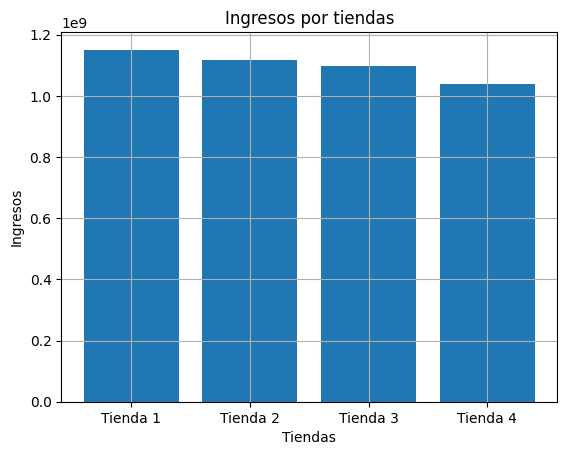

In [104]:
x_values = ingresos_por_tienda_df["Tiendas"]
y_values = ingresos_por_tienda_df["Ingresos"]

plt.bar(x_values, y_values)
plt.title('Ingresos por tiendas')
plt.xlabel("Tiendas")
plt.ylabel("Ingresos")
plt.grid(True)
plt.show()

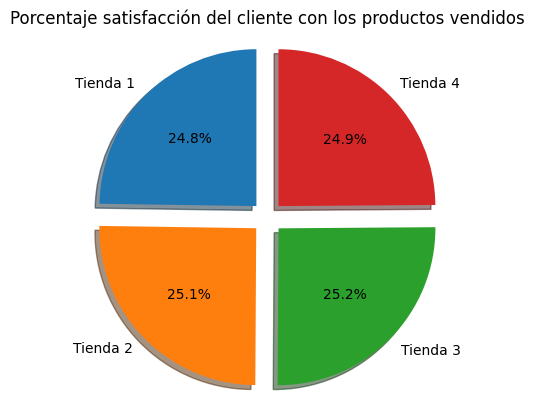

In [105]:
labels =calificacion_pocentaje_tienda_df["Tienda"]
sizes = calificacion_pocentaje_tienda_df["Porcentaje Satisfaccion"]
explode = (0.1, 0.1, 0.1, 0.1)  # Separación de las porciones

plt.title('Porcentaje satisfacción del cliente con los productos vendidos')

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)

plt.axis('equal')  #La relación de aspecto igual garantiza que el círculo sea homogeneo
plt.show()

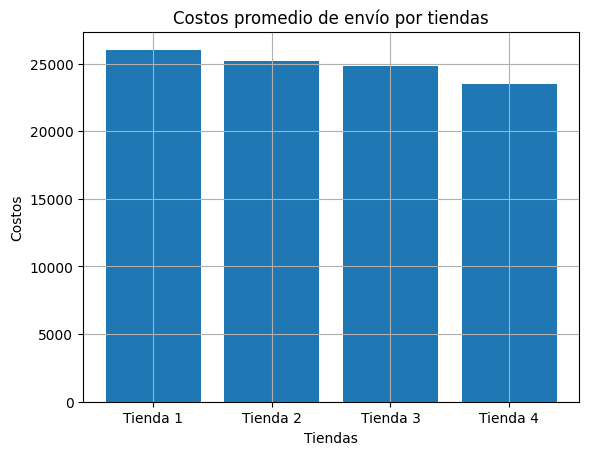

In [106]:
x_values = envio_promedio_tienda_df["Tienda"]
y_values = envio_promedio_tienda_df["Envío Promedio"]

plt.bar(x_values, y_values)
plt.title('Costos promedio de envío por tiendas')
plt.xlabel("Tiendas")
plt.ylabel("Costos")
plt.grid(True)
plt.show()

# Informe final análisis situación cadena Alura Store

Sr. Juan, teniendo en cuenta todos los factores analizados, tales como:

*   Los ingresos totales de las tiendas.
*   Las categorías de productos más y menos vendidas.
*   Las calificaciones promedio de los clientes por tienda.
*   Los productos más y menos vendidos.
*   El coste de envío promedio para cada tienda.

**Justificación:**

1.   **Ingresos por concepto de ventas:**
Los ingresos por concepto de venta de productos en las cuatro tiendas de la cadena Alura Store indican que la Tienda 4 presenta los ingresos más bajos en comparación con las otras tiendas de la cadena.

2.   **Costos por concepto de envío de ventas:**
En relación a los costos de envíos por concepto de ventas, si bien la Tienda 4 presenta los costos mas bajos en comparación a las cuatro tiendas de la cadena Alura Store, su mal desempeño en ventas hace que la relación de los ingresos por venta (considerando los costos de envío) sea la de peor desempeño entre las tiendas.

3.   **Evaluacón de satisfacción por venta:**
Respecto de la satisfacción por parte de los clientes en realación a las compras efectuadas, la Tienda 4 se encuentra como la peor evaluada.

**Recomendación:**

Producto del trabajo y del análisis antes señalado, **se recomienda la venta de la tienda 4** de la cadena Alura Store.

Atte.,

**Gabriel Fuentes Jara**

